<a href="https://colab.research.google.com/github/AdrionRosanelli/LoRa_Sionna/blob/main/Lora_Phy_Tx_Block.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste de Implementação do Transmissor LoRa no Sionna PHY usando Block.**

Implementação realizada a usando a estrutura de block do Sionna:

    

# Implementação do transmissor da camada física do LoRa

*   Implementa geração de chirps
*   Modulação utilizando os chirps
*   Codifica dados em símbolos
*   Gera pacotes do LoRa

### Imports

Instalação e importação das bibliotecas. (Import do tutorial Part 1 Sionna PHY)

In [2]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [3]:
import sionna

from sionna.phy import Block
from sionna.phy.config import Config
from sionna.phy.utils import expand_to_rank
from sionna.phy.mapping import BinarySource
from sionna.phy.fec.crc import CRCEncoder

### Implementação da camada física do LoRa no bloco.

1. Inicialização

  *   Define parâmetros do LoRa.

2. Geração de chirps do LoRa:

  *   Chirp linear variando de 0 a BW.

3. Modulação usando chirp.

4. Calculo da frequência instantânea.

5. Geração de pacotes:

  *   Preâmbulo.
  *   Sincronismo.
  *   Cabeçalho.
  *   Payload.

6. Codificação dos bits

7. Analise do chirp

In [4]:
class LoRaPhyTransmitter(Block):
    """
    Implementação da camada física do transmissor LoRa usando Sionna e tensores TensorFlow
    """

    def __init__(self,
                 spreading_factor=7,      # SF7 = 128 chips por símbolo
                 bandwidth=125e3,         # 125 kHz
                 coding_rate=1,           # Taxa de codificação (1=4/5, 2=4/6, 3=4/7, 4=4/8)
                 num_preamble=8,          # Símbolos de preâmbulo
                 sync_word=0x34,          # Palavra de sincronização
                 crc_on=True,             # Habilitar CRC
                 carrier_freq=None,       # Frequência da portadora (Hz), None para desabilitar
                 debug=False,             # Habilitar prints de debug
                 precision=None,
                 **kwargs):

        super().__init__(precision=precision,**kwargs)

        self.sf = spreading_factor
        self.bw = tf.constant(bandwidth, dtype=tf.float32)
        self.cr = coding_rate
        self.num_preamble = num_preamble
        self.sync_word = sync_word
        self.crc_on = crc_on
        self.carrier_freq = carrier_freq
        self.debug = debug

        # Parâmetros derivados
        self.n_chips = 2**self.sf  # Número de chips por símbolo
        self.symbol_duration = tf.constant(self.n_chips / bandwidth, dtype=tf.float32)
        self.chip_duration = tf.constant(1.0 / bandwidth, dtype=tf.float32)

        # Polinômio CRC-16-CCITT (usado no LoRa)
        self.crc_poly = 0x1021
        self.crc_encoder = CRCEncoder(crc_degree="CRC16")

        # Polinômio CRC-4 para cabeçalho: x^4 + x + 1 (0x13 em hexadecimal)
        self.header_crc_poly = 0x13

        # Polinômio e semente para whitening (novo padrão)
        # Polinômio: x^8 + x^6 + x^5 + x^4 + 1 (0x170 em hexadecimal)
        self.whitening_poly = 0x170
        self.whitening_seed = 0xFF  # Semente inicial (8 bits = 0xFF)

        # Pre-computar vetores de tempo para eficiência
        self._build_time_vectors()

        self.ldr = 0

    def build(self, input_shapes):
        """
        Método build específico do Block - executado na primeira chamada
        Permite inicialização baseada nas formas de entrada
        """
        super().build(input_shapes)

        # Validar formato de entrada
        if len(input_shapes) > 2:
            raise ValueError("Entrada deve ter no máximo 2 dimensões: [batch_size, num_bits] ou [num_bits]")

        # Configurar processamento baseado na forma de entrada
        if len(input_shapes) == 1:
            self.batch_processing = False
        else:
            self.batch_processing = True

        print(f"LoRa Transmitter configurado para entrada: {input_shapes}")

    def _build_time_vectors(self):
        """
        Pre-computa vetores de tempo para os símbolos
        """
        step = self.symbol_duration / self.n_chips
        self.t_symbol = tf.linspace(0.0, self.symbol_duration - step, self.n_chips)

    def generate_chirp_sequence(self, initial_frequency=0.0, down_chirp=False):
        """
        Gera sequência chirp característica do LoRa usando tensores

        Args:
            initial_frequency: Frequência inicial do chirp (Hz)
            down_chirp: Se True, gera down-chirp; se False, gera up-chirp

        Returns:
            chirp: Tensor complexo com o sinal chirp
        """
        # Converter para tensor se necessário
        initial_freq = tf.cast(initial_frequency, tf.float32)

        # Chirp linear com frequência variando de 0 a BW
        if down_chirp:
            freq_slope = -self.bw / self.symbol_duration
        else:
            freq_slope = self.bw / self.symbol_duration

        # Calcular fase instantânea
        phase = 2.0 * np.pi * (
            initial_freq * self.t_symbol +
            0.5 * freq_slope * tf.square(self.t_symbol)
        )

        # Gerar chirp complexo - separando parte real e imaginária para tensor complexo
        real_part = tf.cos(phase)
        imag_part = tf.sin(phase)
        chirp = tf.complex(real_part, imag_part)

        # Converter para o tipo complexo correto do Block
        chirp = tf.cast(chirp, self.cdtype)

        return chirp

    def modulate_symbol(self, symbol_value):
        """
        Modula um símbolo usando modulação chirp do LoRa

        Args:
            symbol_value: Valor do símbolo (0 a 2^SF - 1)

        Returns:
            chirp: Tensor complexo com o sinal modulado
        """
        # Frequência offset baseada no valor do símbolo
        symbol_val = tf.cast(symbol_value, tf.float32)
        freq_offset = (symbol_val * self.bw) / tf.cast(self.n_chips, tf.float32)

        chirp = self.generate_chirp_sequence(freq_offset)
        return chirp

    @tf.function
    def binary_to_gray(self, binary_value):
        """
        Converte binário para código Gray específico do LoRa
        (compatível com gr-lora implementação)

        Args:
            binary_value: Tensor com valores [0, 2^SF-1]

        Returns:
            gray_value: Tensor em código Gray LoRa
        """
        # Inicializa com o valor de entrada
        gray = binary_value

        # XOR acumulado para todos os shifts de 1 até SF-1
        for j in range(1, self.sf):
            shifted = tf.bitwise.right_shift(binary_value, j)
            gray = tf.bitwise.bitwise_xor(gray, shifted)

        # Adiciona offset de +1 módulo 2^SF
        max_val = tf.cast(tf.pow(2.0, tf.cast(self.sf, tf.float32)), tf.int32)
        gray = tf.math.mod(gray + 1, max_val)

        return gray

    @tf.function
    def encode_data_tensor(self, data_symbols):
        """
        Codifica dados em símbolos LoRa a partir de VALORES DECIMAIS já prontos

        Args:
            data_symbols: Tensor 1D com valores decimais [num_symbols] - range [0, 2^SF-1]

        Returns:
            symbols: Tensor complexo [num_symbols, n_chips]
            gray_values: Valores Gray gerados (para debug)
        """
        # Validar range dos símbolos
        max_symbol = tf.cast(tf.pow(2.0, tf.cast(self.sf, tf.float32)), tf.int32)

        # Os valores já são decimais, apenas aplicar Gray mapping
        gray_values = self.binary_to_gray(data_symbols)

        # Modular todos os símbolos usando os valores Gray
        symbols = tf.map_fn(
            lambda x: self.modulate_symbol(x),
            gray_values,
            fn_output_signature=tf.TensorSpec(shape=[self.n_chips], dtype=self.cdtype),
            parallel_iterations=10
        )

        return symbols, gray_values

    @tf.function
    def generate_preamble(self):
        """
        Gera preâmbulo LoRa

        Returns:
            preamble: Tensor complexo [num_preamble, n_chips]
        """
        # Up-chirps para preâmbulo
        base_chirp = self.generate_chirp_sequence(-self.bw/2.0)
        preamble = tf.tile(base_chirp[tf.newaxis, :], [self.num_preamble, 1])
        return preamble

    @tf.function
    def generate_sync_word(self):
        """
        Gera palavra de sincronização

        Returns:
            sync_symbols: Tensor complexo [1, n_chips]
        """
        sync_symbol = self.modulate_symbol(self.sync_word)
        return sync_symbol[tf.newaxis, :]

    @tf.function
    def generate_down_chirps(self):
        """
        Gera 2.25 down-chirps após sincronização

        Returns:
            down_chirps: Tensor complexo [total_samples]
        """
        # Down-chirp completo
        down_chirp = self.generate_chirp_sequence(self.bw/2.0, down_chirp=True)

        # 2 down-chirps completos
        full_chirps = tf.tile(down_chirp[tf.newaxis, :], [2, 1])
        full_chirps = tf.reshape(full_chirps, [-1])

        # 0.25 down-chirp
        quarter_length = self.n_chips // 4
        quarter_chirp = down_chirp[:quarter_length]

        # Concatenar
        down_chirps = tf.concat([full_chirps, quarter_chirp], axis=0)

        return down_chirps

    @tf.function
    def calculate_header_checksum(self, header_bits):
        """
        Calcula checksum de 5 bits para o cabeçalho LoRa usando a matriz de paridade

        A matriz define quais bits do cabeçalho são combinados (via XOR) para cada bit do checksum.
        Operação: checksum[i] = XOR de todos os bits onde matriz[i, j] == 1

        Args:
            header_bits: Tensor 1D com 12 bits do cabeçalho [12]
                        (payload_length: 8 bits + cr: 3 bits + crc_present: 1 bit)

        Returns:
            checksum: Tensor com 5 bits de checksum [5]
        """
        header_checksum_matrix = tf.constant([
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
            [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1],
            [0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0],
            [0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1],
            [0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1],
        ], dtype=tf.int32)

        # Multiplica cada linha da matriz pelos bits do cabeçalho
        # Resultado: [5, 12] onde cada linha tem os bits selecionados
        products = header_checksum_matrix * header_bits

        # Soma cada linha (conta quantos 1's) e aplica mod 2
        # mod 2 implementa XOR: número ímpar de 1's → 1, par → 0
        checksum = tf.math.floormod(tf.reduce_sum(products, axis=1), 2)

        return checksum

    @tf.function
    def generate_header(self, payload_length):
        """
        Gera cabeçalho LoRa (PHDR) com estrutura completa de 20 bits

        Estrutura do PHDR (modo explícito):
        - Payload Length: 8 bits (0-255 bytes)
        - Coding Rate: 3 bits (001=4/5, 010=4/6, 011=4/7, 100=4/8)
        - CRC Present: 1 bit (0=sem CRC, 1=com CRC)
        - Reserved: 3 bits (000)
        - Header CRC: 5 bits (pela matriz)

        Args:
            payload_length: Comprimento do payload em bits

        Returns:
            header_bits: Tensor 1D com 20 bits do cabeçalho completo [20]
        """
        # 1. Payload Length (8 bits) - converter bits para bytes
        payload_bytes = payload_length // 8
        payload_bytes = tf.minimum(payload_bytes, 255)  # Limitar a 255

        # Converter para bits (MSB first)
        length_bits = tf.TensorArray(dtype=tf.int32, size=8)

        def extract_length_bits(i, val, bits_array):
            bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(val, 7 - i), 1
            )
            bits_array = bits_array.write(i, bit)
            return i + 1, val, bits_array

        _, _, length_bits = tf.while_loop(
            lambda i, val, bits_array: i < 8,
            extract_length_bits,
            [0, payload_bytes, length_bits]
        )

        length_bits_tensor = length_bits.stack()

        # 2. Coding Rate (3 bits)
        # CR: 1=001, 2=010, 3=011, 4=100
        cr_bits = tf.TensorArray(dtype=tf.int32, size=3)

        def extract_cr_bits(i, val, bits_array):
            bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(val, 2 - i), 1
            )
            bits_array = bits_array.write(i, bit)
            return i + 1, val, bits_array

        _, _, cr_bits = tf.while_loop(
            lambda i, val, bits_array: i < 3,
            extract_cr_bits,
            [0, self.cr, cr_bits]
        )

        cr_bits_tensor = cr_bits.stack()

        # 3. CRC Present (1 bit)
        crc_bit = tf.constant([1 if self.crc_on else 0], dtype=tf.int32)

        # 4. Reserved bits (3 bits) - todos zeros
        reserved_bits = tf.zeros([3], dtype=tf.int32)

        # Concatenar os primeiros 12 bits (dados do cabeçalho sem reserved bits)
        header_data = tf.concat([
            length_bits_tensor,  # 8 bits
            cr_bits_tensor,      # 3 bits
            crc_bit,             # 1 bit
        ], axis=0)

        # 5. Calcular checksum com a matriz
        header_crc = self.calculate_header_checksum(header_data)

        # 6. Concatenar cabeçalho completo (20 bits)
        complete_header = tf.concat([header_data, reserved_bits, header_crc], axis=0)

        return complete_header


    # =============== Whitening com sequência pré-calculada ===========
    @tf.function
    def whitening(self, final_payload):
        """
        Aplica whitening (scrambling) aos dados do payload usando sequência pré-definida

        O whitening usa uma sequência pseudo-aleatória gerada por LFSR com polinômio
        característico x^8 + x^6 + x^5 + x^4 + 1, aplicada via XOR aos dados.

        Args:
            final_payload: Tensor 1D com bits do payload [num_bits]
            debug_print: Se True, imprime a sequência de whitening utilizada

        Returns:
            whitened_payload: Tensor 1D com bits do payload após whitening [num_bits]
        """
        payload_length = tf.shape(final_payload)[0]

        # Sequência de whitening pré-calculada (256 bytes em hex)
        whitening_sequence_bytes = [
            0xff, 0xfe, 0xfc, 0xf8, 0xf0, 0xe1, 0xc2, 0x85, 0x0b, 0x17, 0x2f, 0x5e,
            0xbc, 0x78, 0xf1, 0xe3, 0xc6, 0x8d, 0x1a, 0x34, 0x68, 0xd0, 0xa0, 0x40,
            0x80, 0x01, 0x02, 0x04, 0x08, 0x11, 0x23, 0x47, 0x8e, 0x1c, 0x38, 0x71,
            0xe2, 0xc4, 0x89, 0x12, 0x25, 0x4b, 0x97, 0x2e, 0x5c, 0xb8, 0x70, 0xe0,
            0xc0, 0x81, 0x03, 0x06, 0x0c, 0x19, 0x32, 0x64, 0xc9, 0x92, 0x24, 0x49,
            0x93, 0x26, 0x4d, 0x9b, 0x37, 0x6e, 0xdc, 0xb9, 0x72, 0xe4, 0xc8, 0x90,
            0x20, 0x41, 0x82, 0x05, 0x0a, 0x15, 0x2b, 0x56, 0xad, 0x5b, 0xb6, 0x6d,
            0xda, 0xb5, 0x6b, 0xd6, 0xac, 0x59, 0xb2, 0x65, 0xcb, 0x96, 0x2c, 0x58,
            0xb0, 0x61, 0xc3, 0x87, 0x0f, 0x1f, 0x3e, 0x7d, 0xfb, 0xf6, 0xed, 0xdb,
            0xb7, 0x6f, 0xde, 0xbd, 0x7a, 0xf5, 0xeb, 0xd7, 0xae, 0x5d, 0xba, 0x74,
            0xe8, 0xd1, 0xa2, 0x44, 0x88, 0x10, 0x21, 0x43, 0x86, 0x0d, 0x1b, 0x36,
            0x6c, 0xd8, 0xb1, 0x63, 0xc7, 0x8f, 0x1e, 0x3c, 0x79, 0xf3, 0xe7, 0xce,
            0x9c, 0x39, 0x73, 0xe6, 0xcc, 0x98, 0x31, 0x62, 0xc5, 0x8b, 0x16, 0x2d,
            0x5a, 0xb4, 0x69, 0xd2, 0xa4, 0x48, 0x91, 0x22, 0x45, 0x8a, 0x14, 0x29,
            0x52, 0xa5, 0x4a, 0x95, 0x2a, 0x54, 0xa9, 0x53, 0xa7, 0x4e, 0x9d, 0x3b,
            0x77, 0xee, 0xdd, 0xbb, 0x76, 0xec, 0xd9, 0xb3, 0x67, 0xcf, 0x9e, 0x3d,
            0x7b, 0xf7, 0xef, 0xdf, 0xbf, 0x7e, 0xfd, 0xfa, 0xf4, 0xe9, 0xd3, 0xa6,
            0x4c, 0x99, 0x33, 0x66, 0xcd, 0x9a, 0x35, 0x6a, 0xd4, 0xa8, 0x51, 0xa3,
            0x46, 0x8c, 0x18, 0x30, 0x60, 0xc1, 0x83, 0x07, 0x0e, 0x1d, 0x3a, 0x75,
            0xea, 0xd5, 0xaa, 0x55, 0xab, 0x57, 0xaf, 0x5f, 0xbe, 0x7c, 0xf9, 0xf2,
            0xe5, 0xca, 0x94, 0x28, 0x50, 0xa1, 0x42, 0x84, 0x09, 0x13, 0x27, 0x4f,
            0x9f, 0x3f, 0x7f
        ]

        # Converter bytes para bits (LSB primeiro)
        whitening_bits_list = []
        for byte_val in whitening_sequence_bytes:
            # for bit_pos in range(8):
            #     bit = (byte_val >> bit_pos) & 1
            #     whitening_bits_list.append(bit)
            for bit_pos in range(7, -1, -1):
                bit = (byte_val >> bit_pos) & 1
                whitening_bits_list.append(bit)

        # Criar tensor com a sequência de bits (repetir se necessário)
        whitening_bits_full = tf.constant(whitening_bits_list, dtype=tf.int32)

        # Repetir a sequência se o payload for maior que 256 bytes (2048 bits)
        num_repeats = tf.cast(tf.math.ceil(tf.cast(payload_length, tf.float32) / 2048.0), tf.int32)
        whitening_bits_repeated = tf.tile(whitening_bits_full, [num_repeats])

        # Truncar para o tamanho exato do payload
        whitening_bits = whitening_bits_repeated[:payload_length]

        # Aplicar whitening via XOR
        whitened_payload = tf.bitwise.bitwise_xor(
            tf.cast(final_payload, tf.int32),
            whitening_bits
        )

        # return tf.cast(whitened_payload, tf.int32)

        # Separar em nibbles e inverter (Low nibble primeiro, High nibble depois)
        # Garantir que temos múltiplo de 8 bits (completar com zeros se necessário)
        num_bits = tf.shape(whitened_payload)[0]
        padding_needed = (8 - (num_bits % 8)) % 8

        if padding_needed > 0:
            padding = tf.zeros([padding_needed], dtype=tf.int32)
            whitened_payload_padded = tf.concat([whitened_payload, padding], axis=0)
        else:
            whitened_payload_padded = whitened_payload

        # Reshape para bytes (cada linha é um byte de 8 bits)
        num_bytes = tf.shape(whitened_payload_padded)[0] // 8
        bytes_matrix = tf.reshape(whitened_payload_padded, [num_bytes, 8])

        # Separar nibbles: bits [7:4] = high nibble, bits [3:0] = low nibble
        # Formato atual: [b7, b6, b5, b4, b3, b2, b1, b0]
        high_nibble = bytes_matrix[:, 0:4]  # bits 7-4
        low_nibble = bytes_matrix[:, 4:8]   # bits 3-0

        # Inverter: colocar low nibble primeiro, depois high nibble
        # Novo formato: [b3, b2, b1, b0, b7, b6, b5, b4]
        swapped_bytes = tf.concat([low_nibble, high_nibble], axis=1)

        # Flatten de volta para 1D
        nibble_swapped_payload = tf.reshape(swapped_bytes, [-1])

        # Remover padding se foi adicionado
        if padding_needed > 0:
            nibble_swapped_payload = nibble_swapped_payload[:num_bits]

        return tf.cast(nibble_swapped_payload, tf.int32)

    def add_lora_crc(self, payload_bits):
        """
        Adiciona CRC compatível com LoRa ao payload.

        O resultado separa o CRC em 4 nibbles e os adiciona na seguinte ordem:
        - nibble0 = bits [3:0]
        - nibble1 = bits [7:4]
        - nibble2 = bits [11:8]
        - nibble3 = bits [15:12]

        Args:
            payload_bits: Tensor de bits do payload [0,1,0,1,...]

        Returns:
            Tensor com 16 bits de CRC (como 4 nibbles de 4 bits cada)
        """
        bits_np = payload_bits.numpy()
        total_bits = len(bits_np)

        # 1. Separar os bits: primeiros N-16 bits para CRC, últimos 16 bits para XOR
        bits_for_crc = bits_np[:-16]  # Todos exceto últimos 2 bytes (16 bits)
        last_16_bits = bits_np[-16:]   # Últimos 2 bytes

        # 2. Calcular CRC diretamente nos bits
        crc_bits_tensor = self.crc_encoder(tf.constant(bits_for_crc, dtype=tf.int32))
        crc_bits = crc_bits_tensor.numpy()

        # 3. Converter apenas os últimos 16 bits e o CRC para inteiros (para XOR)
        crc_int = int(''.join(map(str, crc_bits)), 2)
        last_byte_n_minus_1 = int(''.join(map(str, last_16_bits[0:8])), 2)  # Penúltimo byte
        last_byte_n = int(''.join(map(str, last_16_bits[8:16])), 2)         # Último byte

        # 4. XOR com os últimos 2 bytes (específico do LoRa)
        crc_lora = crc_int ^ last_byte_n ^ (last_byte_n_minus_1 << 8)
        crc_lora &= 0xFFFF

        # print(f"\n=== DEBUG CRC ===")
        # print(f"CRC calculado: 0x{crc_int:04X}")
        # print(f"Penúltimo byte: 0x{last_byte_n_minus_1:02X}")
        # print(f"Último byte: 0x{last_byte_n:02X}")
        # print(f"CRC após XOR: 0x{crc_lora:04X}")

        nibble0 = (crc_lora & 0x000F)        # bits [3:0]
        nibble1 = (crc_lora & 0x00F0) >> 4   # bits [7:4]
        nibble2 = (crc_lora & 0x0F00) >> 8   # bits [11:8]
        nibble3 = (crc_lora & 0xF000) >> 12  # bits [15:12]

        # print(f"Nibbles: [0x{nibble0:X}, 0x{nibble1:X}, 0x{nibble2:X}, 0x{nibble3:X}]")

        # 6. Converter cada nibble para 4 bits (MSB first dentro de cada nibble)
        def nibble_to_bits(nibble_val):
            return [(nibble_val >> (3-i)) & 1 for i in range(4)]

        # Concatenar nibbles na ordem: nibble0, nibble1, nibble2, nibble3
        crc_final_bits = []
        crc_final_bits.extend(nibble_to_bits(nibble0))
        crc_final_bits.extend(nibble_to_bits(nibble1))
        crc_final_bits.extend(nibble_to_bits(nibble2))
        crc_final_bits.extend(nibble_to_bits(nibble3))

        # # Verificação: reconstruir hex a partir dos bits
        # crc_hex_verification = hex(int(''.join(map(str, crc_final_bits)), 2))[2:].upper().zfill(4)
        # print(f"CRC em bits resulta em: 0x{crc_hex_verification}")
        # print(f"=================\n")

        return tf.constant(crc_final_bits, dtype=payload_bits.dtype)

    @tf.function
    def hamming_encode_tensor(self, data_bits):
        """
        Codifica um tensor de bits usando codificação de Hamming bloco a bloco

        Versão otimizada que processa todos os blocos vetorizadamente

        Args:
            data_bits: Tensor 1D com bits de dados [num_bits]

        Returns:
            encoded_bits: Tensor 1D com bits codificados [num_encoded_bits]
        """
        if self.cr == 0:
            return data_bits  # Sem codificação

        data_bits = tf.cast(data_bits, tf.int32)
        num_bits = tf.shape(data_bits)[0]
        num_blocks = tf.cast(tf.math.ceil(tf.cast(num_bits, tf.float32) / 4.0), tf.int32)

        # Padding para completar blocos de 4 bits
        padded_bits = tf.pad(data_bits, [[0, num_blocks * 4 - num_bits]])
        data_blocks = tf.reshape(padded_bits, [num_blocks, 4])

        # Extrair todos os bits de todos os blocos de uma vez
        d0 = data_blocks[:, 0]
        d1 = data_blocks[:, 1]
        d2 = data_blocks[:, 2]
        d3 = data_blocks[:, 3]

        # Determinar CR para cada bloco (primeiros sf-2 usam CR=4)
        block_indices = tf.range(num_blocks, dtype=tf.int32)
        cr_per_block = tf.where(
            block_indices < (self.sf - 2),
            tf.fill([num_blocks], 4),
            tf.fill([num_blocks], self.cr)
        )

        # Calcular bits de paridade para todos os blocos
        p0 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d2), d1)
        p1 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d2, d1), d0)
        p2 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d2), d0)
        p3 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d1), d0)

        # Para CR = 1 (coding rate 4/5), usar apenas um bit de paridade
        p4 = tf.bitwise.bitwise_xor(
            tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d0, d1), d2),
            d3
        )

        # Montar bytes baseado no CR
        # CR = 1: data LSB first + 1 bit de paridade
        bytes_cr1 = (
            tf.bitwise.left_shift(d3, 4) |
            tf.bitwise.left_shift(d2, 3) |
            tf.bitwise.left_shift(d1, 2) |
            tf.bitwise.left_shift(d0, 1) |
            p4
        )

        # Montar bytes completos para todos os blocos com CR != 1
        bytes_cr_other = (
            tf.bitwise.left_shift(d3, 7) |
            tf.bitwise.left_shift(d2, 6) |
            tf.bitwise.left_shift(d1, 5) |
            tf.bitwise.left_shift(d0, 4) |
            tf.bitwise.left_shift(p0, 3) |
            tf.bitwise.left_shift(p1, 2) |
            tf.bitwise.left_shift(p2, 1) |
            p3
        )

        # Calcular shift para cada bloco baseado no CR !=1
        shift_amounts = 4 - cr_per_block

        # Aplicar shifts
        shifted_bytes = tf.bitwise.right_shift(bytes_cr_other, shift_amounts)


        # Selecionar byte correto baseado no CR
        final_bytes = tf.where(
            tf.equal(cr_per_block, 1),
            bytes_cr1,
            shifted_bytes
        )

        # Determinar número de bits de saída por bloco
        bits_per_block = 4 + cr_per_block

        # Converter bytes para bits usando TensorArray para tamanhos variáveis
        result_array = tf.TensorArray(dtype=tf.int32, size=0, dynamic_size=True)
        write_idx = 0

        def process_block(i, ta, w_idx):
            """Processa um bloco e adiciona bits ao TensorArray"""
            byte_val = final_bytes[i]
            num_bits_out = bits_per_block[i]

            # Extrair bits deste bloco
            def extract_bit(j, ta_inner, idx):
                bit_position = num_bits_out - 1 - j
                bit = tf.bitwise.bitwise_and(
                    tf.bitwise.right_shift(byte_val, bit_position),
                    1
                )
                ta_inner = ta_inner.write(idx, bit)
                return j + 1, ta_inner, idx + 1

            _, ta_updated, idx_updated = tf.while_loop(
                lambda j, ta_inner, idx: j < num_bits_out,
                extract_bit,
                [0, ta, w_idx]
            )

            return i + 1, ta_updated, idx_updated

        # Processar todos os blocos
        _, final_array, _ = tf.while_loop(
            lambda i, ta, w_idx: i < num_blocks,
            process_block,
            [0, result_array, write_idx]
        )

        # Converter para tensor
        encoded_bits = final_array.stack()

        return encoded_bits

    @tf.function
    def interleaving(self, coded_bits):
        """
        Aplica interleaving diagonal LoRa conforme GNU Radio

        Args:
            coded_bits: Tensor 1D com bits codificados

        Returns:
            interleaved_symbols: Tensor 1D com símbolos após interleaving
        """

        # Header: primeiros (SF-2) símbolos com rdd=8
        sf_app_header = self.sf - 2
        cw_len_header = 8  # 4 + 4 (sempre usa CR=4)
        header_bits_needed = sf_app_header * cw_len_header

        # Interleave header
        header_bits = coded_bits[:header_bits_needed]
        header_symbols = self._diag_interleave_block(
            header_bits,
            sf_app=sf_app_header,
            cw_len=cw_len_header,
            add_parity=tf.constant(True)  # Primeiro bloco sempre tem paridade
        )

        # Payload: usa CR configurado
        payload_bits = coded_bits[header_bits_needed:]
        num_payload_bits = tf.shape(payload_bits)[0]

        def process_payload():
            # Parâmetros do payload
            sf_app_payload = self.sf - 2 * self.ldr  # ppm
            cw_len_payload = self.cr + 4
            bits_per_block = sf_app_payload * cw_len_payload

            # Calcular número de blocos
            num_blocks = tf.cast(
                tf.math.ceil(tf.cast(num_payload_bits, tf.float32) /
                           tf.cast(bits_per_block, tf.float32)),
                tf.int32
            )

            # Padding se necessário
            total_bits_needed = num_blocks * bits_per_block
            padding_needed = total_bits_needed - num_payload_bits

            padded_payload = tf.cond(
                padding_needed > 0,
                lambda: tf.concat([payload_bits,
                                  tf.zeros([padding_needed], dtype=coded_bits.dtype)],
                                 axis=0),
                lambda: payload_bits
            )

            # Reshape em blocos
            blocks = tf.reshape(padded_payload, [num_blocks, bits_per_block])

            # Processar cada bloco
            payload_symbols = tf.map_fn(
                lambda block: self._diag_interleave_block(
                    block,
                    sf_app=sf_app_payload,
                    cw_len=cw_len_payload,
                    add_parity=tf.constant(self.ldr > 0)  # Paridade se LDRO ativo
                ),
                blocks,
                fn_output_signature=tf.TensorSpec(shape=[None], dtype=tf.int32)
            )

            return tf.reshape(payload_symbols, [-1])

        # Processar payload se houver bits
        payload_symbols = tf.cond(
            num_payload_bits > 0,
            process_payload,
            lambda: tf.constant([], dtype=tf.int32)
        )

        # Concatenar header e payload
        return tf.concat([header_symbols, payload_symbols], axis=0)

    @tf.function
    def _diag_interleave_block(self, block_bits, sf_app, cw_len, add_parity):
        """
        Interleaving diagonal de um bloco:

        1. Converte bits em codewords (sf_app codewords de cw_len bits cada)
        2. Monta matriz [sf_app x cw_len] onde cw_bin[j] = codeword j
        3. Cria inter_bin [cw_len x m_sf] inicializada com zeros
        4. Interleaving: inter_bin[i][j] = cw_bin[mod(i-j-1, sf_app)][i] para j < sf_app
        5. Adiciona bit de paridade se necessário: inter_bin[i][sf_app] = parity
        6. Converte cada linha inter_bin[i] (m_sf bits) para símbolo decimal

        Args:
            block_bits: Bits do bloco [sf_app * cw_len]
            sf_app: Spreading Factor aplicado (sf-2 ou sf-2*ldr)
            cw_len: Comprimento do codeword (4+cr)
            add_parity: Se deve adicionar bit de paridade

        Returns:
            symbols: Símbolos após interleaving [cw_len]
        """

        # Reshape bits em codewords [sf_app, cw_len]
        cw_bin = tf.reshape(block_bits, [sf_app, cw_len])

        # Criar matriz inter_bin [cw_len, m_sf] inicializada com zeros
        # GNU Radio: std::vector<std::vector<bool>> inter_bin(cw_len, init_bit(m_sf, 0))
        inter_bin = tf.zeros([cw_len, self.sf], dtype=block_bits.dtype)

        # Criar índices para o interleaving diagonal
        # inter_bin[i][j] = cw_bin[mod(i-j-1, sf_app)][i] para j in range(sf_app)
        i_indices = tf.range(cw_len)
        j_indices = tf.range(sf_app)

        # Broadcast para criar todas as combinações
        i_grid = tf.expand_dims(i_indices, 1)  # [cw_len, 1]
        j_grid = tf.expand_dims(j_indices, 0)  # [1, sf_app]

        # Calcular índices fonte: mod(i-j-1, sf_app)
        source_indices = tf.math.floormod(i_grid - j_grid - 1, sf_app)

        # Gather bits usando os índices calculados
        interleaved_core = tf.gather_nd(
            cw_bin,
            tf.stack([
                tf.reshape(source_indices, [-1]),
                tf.repeat(i_indices, sf_app)
            ], axis=1)
        )
        interleaved_core = tf.reshape(interleaved_core, [cw_len, sf_app])

        # Copiar bits interleaved para as primeiras sf_app colunas de inter_bin
        indices_to_update = tf.stack([
            tf.repeat(tf.range(cw_len), sf_app),
            tf.tile(tf.range(sf_app), [cw_len])
        ], axis=1)

        inter_bin = tf.tensor_scatter_nd_update(
            inter_bin,
            indices_to_update,
            tf.reshape(interleaved_core, [-1])
        )

        # Adicionar bit de paridade na posição sf_app se necessário
        def with_parity():
            # Calcular paridade para cada linha (XOR dos primeiros sf_app bits)
            parity_bits = tf.math.floormod(
                tf.reduce_sum(tf.cast(interleaved_core, tf.int32), axis=1),
                2
            )
            parity_bits = tf.cast(parity_bits, block_bits.dtype)

            # Atualizar coluna sf_app com bits de paridade
            parity_indices = tf.stack([
                tf.range(cw_len),
                tf.fill([cw_len], sf_app)
            ], axis=1)

            return tf.tensor_scatter_nd_update(
                inter_bin,
                parity_indices,
                parity_bits
            )

        inter_bin = tf.cond(
            add_parity,
            with_parity,
            lambda: inter_bin
        )

        # Converter cada linha de bits para decimal
        # Criar pesos: [2^(sf-1), 2^(sf-2), ..., 2^1, 2^0]
        powers = tf.cast(
            2 ** tf.range(self.sf - 1, -1, -1),
            tf.int32
        )

        symbols = tf.reduce_sum(
            tf.cast(inter_bin, tf.int32) * powers,
            axis=1
        )

        return symbols



    def call(self, inputs):
        """
        Processa o sinal de entrada e gera pacote LoRa completo

        Args:
            inputs: Tensor com bits de dados [batch_size, num_bits] ou [num_bits]

        Returns:
            lora_packet: Tensor complexo com pacote LoRa modulado
        """
        # Garantir que inputs seja um tensor e int32 para lógica binaria
        payload_bits = tf.convert_to_tensor(inputs)
        payload_bits = tf.cast(payload_bits, tf.int32)

        # Expandir dimensões se necessário para suportar batch
        if len(payload_bits.shape) == 1:
            payload_bits = payload_bits[tf.newaxis, :]

        batch_size = tf.shape(payload_bits)[0]

        # Processar cada item do batch
        def process_single_packet(payload):
            # 1. Gerar preâmbulo
            preamble = self.generate_preamble()
            preamble_flat = tf.reshape(preamble, [-1])

            # 2. Gerar palavra de sincronização
            sync_word = self.generate_sync_word()
            sync_flat = tf.reshape(sync_word, [-1])

            # 3. Gerar down-chirps
            down_chirps = self.generate_down_chirps()

            # 4. Aplicar whitening se habilitado
            if self.debug:
                print(f"\nPayload Original: {payload}")
                payl_hex = hex(int(''.join(map(str, payload.numpy())), 2))[2:].upper()
                print(f"Payload Original em Hex: {payl_hex}")

            payload_processed = self.whitening(payload)

            if self.debug:
                print(f"Payload Depois de Whitening: {payload_processed}")
                whit_hex = hex(int(''.join(map(str, payload_processed.numpy())), 2))[2:].upper()
                print(f"Payload Depois de Whitening em Hex: {whit_hex}")

            # 5. Gerar cabeçalho LoRa (PHDR) com estrutura completa
            payload_length = tf.shape(payload_processed)[0]
            header_bits = self.generate_header(payload_length)

            if self.debug:
              print(f"\nCabeçalho LoRa (20 bits): {header_bits}")
              print(f"  - Payload Length: {payload_length // 8} bytes")
              print(f"  - Coding Rate: {self.cr}")
              print(f"  - CRC Present: {self.crc_on}")

            # 6. Concatenar Header + Payload (com whitening)
            header_payload = tf.concat([header_bits, payload_processed], axis=0)
            if self.debug:
              print(f"\nHeader + Payload: {header_payload}")
              hp_hex = hex(int(''.join(map(str, header_payload.numpy())), 2))[2:].upper()
              print(f"Header + Payload em Hex: {hp_hex}")

            # 7. Calcular e adicionar CRC (do Header + Payload)
            if self.crc_on:
                # header_payload_crc = self.crc_encoder(header_payload)
                crc_result = self.add_lora_crc(payload)
                header_payload_crc = tf.concat([header_payload, crc_result], axis=0)
                if self.debug:
                  print(f"\nHeader + Payload + CRC: {header_payload_crc}")
                  crc_hex = hex(int(''.join(map(str, header_payload_crc.numpy())), 2))[2:].upper()
                  print(f"Header + Payload + CRC em Hex: {crc_hex}")
            else:
                header_payload_crc = header_payload


            # 8. Aplicar codificação de Hamming
            coded_bits = self.hamming_encode_tensor(header_payload_crc)
            if self.debug:
              print(f"\nDepois de Hamming: {coded_bits}")
              Hamm_hex = hex(int(''.join(map(str, coded_bits.numpy())), 2))[2:].upper()
              print(f"Depois de Hamming em Hex: {Hamm_hex}")

            # 9. Aplicar interleaving
            interleaved_bits = self.interleaving(coded_bits)
            if self.debug:
              print(f"\nDepois de Interleaving: {interleaved_bits}")

            # 10. Codificar e modular
            data_symbols, gray_values = self.encode_data_tensor(interleaved_bits)
            data_flat = tf.reshape(data_symbols, [-1])
            if self.debug:
              print(f"\nDepois do gray: {gray_values}")

            # ===== MONTAGEM DO PACOTE =====

            # 11. Concatenar todas as partes (Preâmbulo + Sync + Down-chirps + Dados)
            packet_parts = [preamble_flat, sync_flat, down_chirps, data_flat]
            baseband_signal = tf.concat(packet_parts, axis=0)

            # 12. Aplicar modulação da portadora se habilitada
            if self.carrier_freq is not None:
                signal_length = tf.shape(baseband_signal)[0]
                time_vector = tf.linspace(0.0,
                                        tf.cast(signal_length, tf.float32) * self.chip_duration,
                                        signal_length)
                # Criar portadora complexa
                carrier_real = tf.cos(2.0 * np.pi * self.carrier_freq * time_vector)
                carrier_imag = tf.sin(2.0 * np.pi * self.carrier_freq * time_vector)
                carrier = tf.complex(carrier_real, carrier_imag)
                carrier = tf.cast(carrier, self.cdtype)

                final_signal = baseband_signal * carrier
            else:
                final_signal = baseband_signal

            return final_signal

        # Aplicar processamento a todo o batch
        if batch_size == 1:
            result = process_single_packet(payload_bits[0])
            return result[tf.newaxis, :]
        else:
            results = tf.map_fn(
                process_single_packet,
                payload_bits,
                fn_output_signature=tf.TensorSpec(shape=[None], dtype=self.cdtype),
                parallel_iterations=1
            )
            return results

#######################################################
## Funções para visualização e analises da implementação:

    def plot_frequency_vs_time(self, packet_signal, title="Variação de Frequência do Pacote LoRa"):
        """
        Plota a variação de frequência instantânea em função do tempo

        Args:
            packet_signal: Sinal do pacote LoRa (tensor complexo)
            title: Título do gráfico
        """
        # Converter para numpy para processamento
        signal = packet_signal.numpy() if hasattr(packet_signal, 'numpy') else packet_signal

        # Calcular frequência instantânea usando diferenciação da fase
        analytic_signal = signal
        phase = np.unwrap(np.angle(analytic_signal))

        # Frequência instantânea = derivada da fase / (2*pi)
        dt = self.chip_duration.numpy()
        freq_inst = np.diff(phase) / (2 * np.pi * dt)

        # Eixo temporal
        time_axis = np.arange(len(freq_inst)) * dt * 1000  # ms

        # Plotar
        plt.figure(figsize=(10, 3))

        plt.plot(time_axis, freq_inst / 1000, 'b-o', linewidth=1, markersize=2)
        plt.title(title)
        plt.xlabel('Tempo (ms)')
        plt.ylabel('Frequência Instantânea (kHz)')
        plt.grid(True, alpha=0.3)

        # Adicionar linhas de referência para bandwidth
        bw_khz = self.bw.numpy() / 1000
        plt.axhline(y=bw_khz/2, color='r', linestyle='--', alpha=0.7, label=f'+BW/2 = {bw_khz/2:.1f} kHz')
        plt.axhline(y=-bw_khz/2, color='r', linestyle='--', alpha=0.7, label=f'-BW/2 = {-bw_khz/2:.1f} kHz')
        plt.legend()

        plt.tight_layout()
        plt.show()

        return freq_inst, time_axis


### Testes e Simulação do modelo

Inicialização e configuração da LoRa PHY:

In [5]:
print("=== Simulação da Camada Física do Transmissor LoRa com Sionna ===\n")

# Criar transmissor
transmitter = LoRaPhyTransmitter(
    spreading_factor=7,
    bandwidth=125e3,
    coding_rate=1,
    crc_on=True,
    debug=False
)

# Dados BinarySource
binary_source = sionna.phy.mapping.BinarySource()
batch_size = 100
num_bits = 80
bits = binary_source([batch_size, num_bits])
print(f"Gerando {batch_size} pacotes com {num_bits} bits cada...")

# # Dados hex
# hex_data = ['1122']
# # Conversão para bits (formato do BinarySource)
# bits_list = []
# for hex_string in hex_data:
#     byte_array = bytes.fromhex(hex_string)
#     bits = np.unpackbits(np.frombuffer(byte_array, dtype=np.uint8))
#     bits_list.append(bits)

# bits = tf.constant(np.array(bits_list), dtype=tf.float32)
# print(bits)

# Gerar pacote LoRa
lora_packets = transmitter(bits)

print(f"\nForma do pacote LoRa: {lora_packets.shape}")
print(f"Tipo do tensor: {lora_packets.dtype}")
print(f"Precisão do transmissor: {transmitter.cdtype}")
print("\nTransmissor LoRa para Sionna implementado com sucesso!\n")


print(f"Configurações LoRa:")
print(f"- Spreading Factor: {transmitter.sf}")
print(f"- Largura de Banda: {transmitter.bw/1000:.0f} kHz")
print(f"- Chips por símbolo: {transmitter.n_chips}")
print(f"- Duração do símbolo: {transmitter.symbol_duration*1000:.2f} ms")
print(f"- Taxa de símbolo: {1/transmitter.symbol_duration:.2f} símbolos/s\n")

=== Simulação da Camada Física do Transmissor LoRa com Sionna ===

Gerando 100 pacotes com 80 bits cada...
LoRa Transmitter configurado para entrada: (100, 80)

Forma do pacote LoRa: (100, 5024)
Tipo do tensor: <dtype: 'complex64'>
Precisão do transmissor: <dtype: 'complex64'>

Transmissor LoRa para Sionna implementado com sucesso!

Configurações LoRa:
- Spreading Factor: 7
- Largura de Banda: 125 kHz
- Chips por símbolo: 128
- Duração do símbolo: 1.02 ms
- Taxa de símbolo: 976.56 símbolos/s



Comprimento dos pacotes: [5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024, 5024] samples
Duração total do pacote: 40.19 ms

Análise de frequência vs tempo:


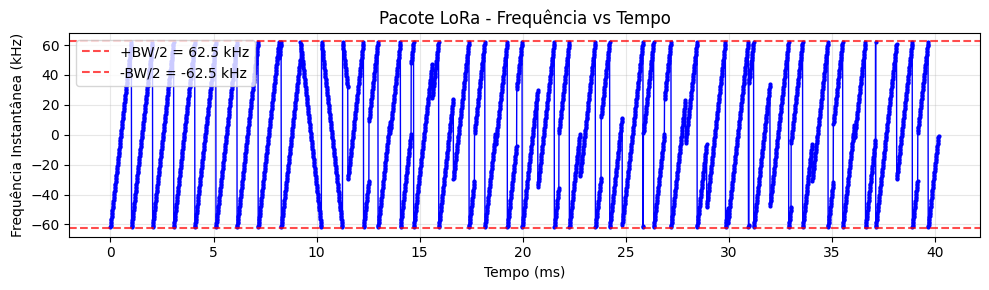

Frequência instantânea calculada para 5023 amostras
Duração total analisada: 40.2 ms

Transmissor LoRa para Sionna implementado e testado com sucesso!


In [6]:
# Análise dos sinais gerados
packet_lengths = [tf.shape(packet)[0] for packet in tf.unstack(lora_packets)]
print(f"Comprimento dos pacotes: {[length.numpy() for length in packet_lengths]} samples")

# Calcular duração temporal dos pacotes
total_duration = packet_lengths[0].numpy() * transmitter.chip_duration.numpy()
print(f"Duração total do pacote: {total_duration*1000:.2f} ms")


# Análise de frequência vs tempo do pacote
print("\n" + "="*50)
print("Análise de frequência vs tempo:")

try:
    # Usar o primeiro pacote do batch para análise detalhada
    single_packet_for_analysis = lora_packets[0]
    freq_inst, time_axis = transmitter.plot_frequency_vs_time(
        single_packet_for_analysis,
        "Pacote LoRa - Frequência vs Tempo"
    )

    print(f"Frequência instantânea calculada para {len(freq_inst)} amostras")
    print(f"Duração total analisada: {time_axis[-1]:.1f} ms")

    # # Usar o primeiro pacote do batch para análise detalhada
    # single_packet_for_analysis = lora_packets[1]
    # freq_inst, time_axis = transmitter.plot_frequency_vs_time(
    #     single_packet_for_analysis,
    #     "Pacote 2 LoRa - Frequência vs Tempo"
    # )

    # print(f"Frequência instantânea calculada para {len(freq_inst)} amostras")
    # print(f"Duração total analisada: {time_axis[-1]:.1f} ms")

    # Análise estrutural completa
    #sections = transmitter.analyze_lora_packet_structure(single_packet_for_analysis)

except Exception as e:
    print(f"Erro na análise de frequência: {e}")
    import traceback
    traceback.print_exc()

print("\nTransmissor LoRa para Sionna implementado e testado com sucesso!")

#### Análise de Eficiência Computacional

Testes de dempenho

ANÁLISE DE EFICIÊNCIA COMPUTACIONAL DO TRANSMISSOR LORA

📊 TESTE 1: Impacto do Batch Size
----------------------------------------------------------------------
LoRa Transmitter configurado para entrada: (1, 80)
Batch=  1 | Tempo=0.0462±0.0009s | Throughput=21.6 pkt/s | 46.20 ms/pkt
LoRa Transmitter configurado para entrada: (10, 80)
Batch= 10 | Tempo=0.4764±0.0143s | Throughput=21.0 pkt/s | 47.64 ms/pkt
LoRa Transmitter configurado para entrada: (50, 80)
Batch= 50 | Tempo=2.6244±0.3888s | Throughput=19.1 pkt/s | 52.49 ms/pkt
LoRa Transmitter configurado para entrada: (100, 80)
Batch=100 | Tempo=5.7108±1.0178s | Throughput=17.5 pkt/s | 57.11 ms/pkt
LoRa Transmitter configurado para entrada: (200, 80)
Batch=200 | Tempo=9.8892±0.3992s | Throughput=20.2 pkt/s | 49.45 ms/pkt
LoRa Transmitter configurado para entrada: (500, 80)
Batch=500 | Tempo=25.8785±0.2879s | Throughput=19.3 pkt/s | 51.76 ms/pkt

📊 TESTE 2: Impacto do Tamanho do Payload
--------------------------------------------------

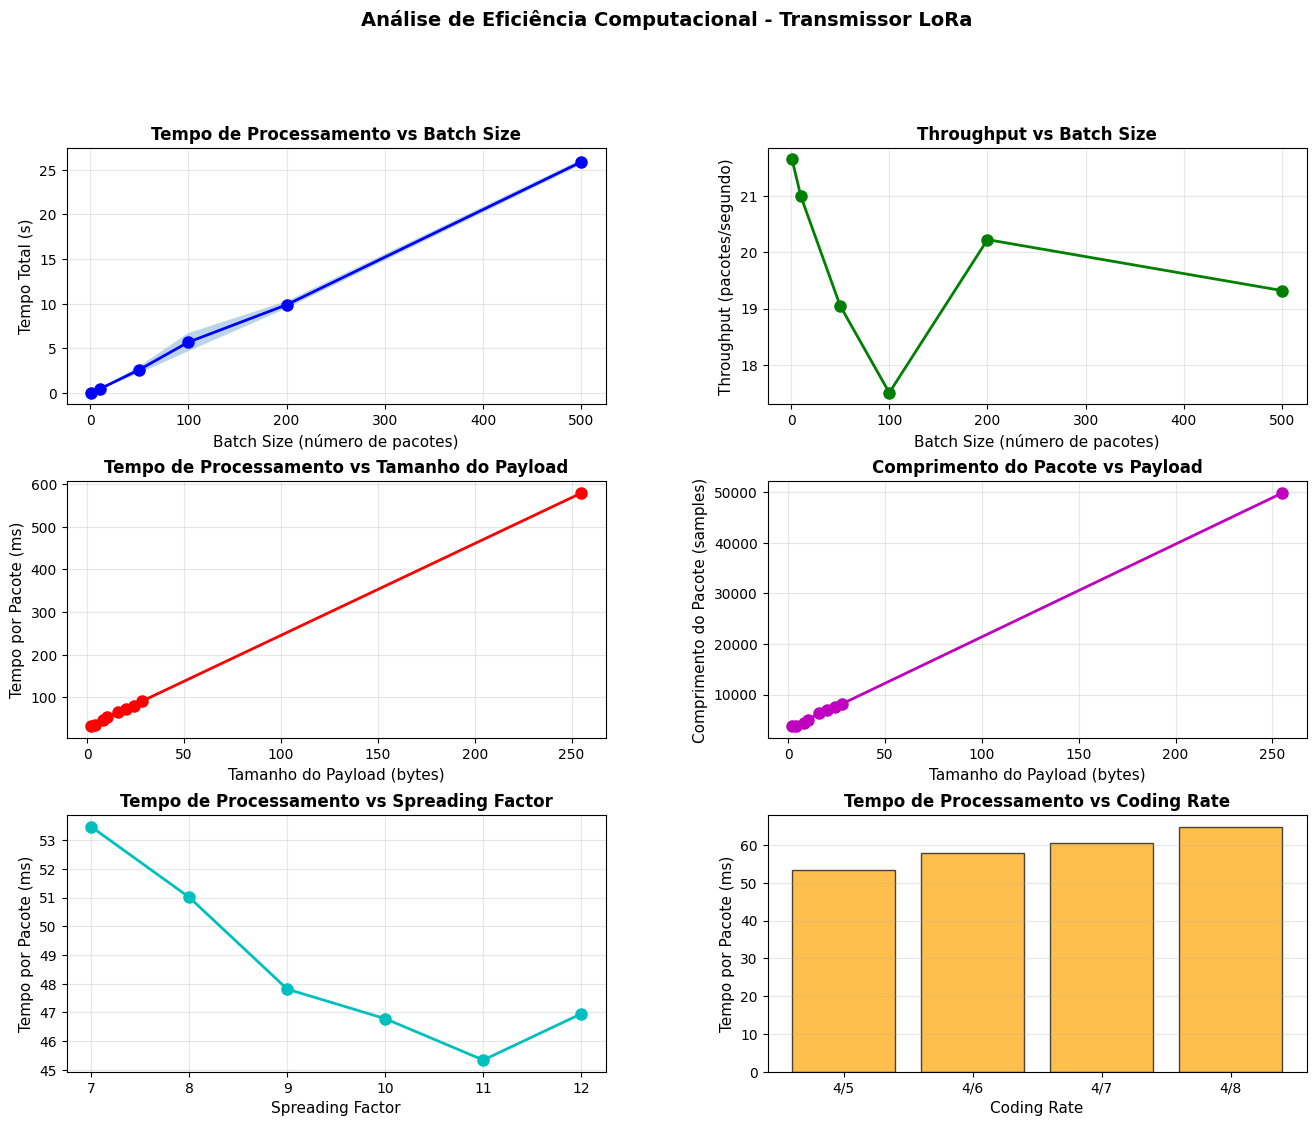


📋 RESUMO ESTATÍSTICO

🔹 Configuração Base:
   • Spreading Factor: 7
   • Bandwidth: 125 kHz
   • Coding Rate: 1 (4/5)
   • CRC: Habilitado

🔹 Melhor Performance (Batch Size):
   • Batch Size: 1
   • Throughput: 21.6 pacotes/s
   • Tempo/Pacote: 46.20 ms

🔹 Escalabilidade Linear:
   • Speedup Real: 0.89x
   • Speedup Ideal: 500.00x
   • Eficiência: 0.2%

🔹 Impacto do Payload:
   • Aumento de tempo: 18.15x
   • Para payload 2→255 bytes

✅ Análise de eficiência computacional concluída!


In [7]:
# ===================================================================
# ANÁLISE DE EFICIÊNCIA COMPUTACIONAL
# ===================================================================

import time
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

print("="*70)
print("ANÁLISE DE EFICIÊNCIA COMPUTACIONAL DO TRANSMISSOR LORA")
print("="*70)

# Configurações base para os testes
base_config = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False
}

# ===================================================================
# TESTE 1: Variação do número de pacotes (batch size)
# ===================================================================
print("\n📊 TESTE 1: Impacto do Batch Size")
print("-" * 70)

batch_sizes = [1, 10, 50, 100, 200, 500]
batch_results = []

num_bits = 80  # Tamanho fixo do payload

for batch_size in batch_sizes:
    # Criar transmissor
    tx = LoRaPhyTransmitter(**base_config)

    # Gerar dados
    bits = binary_source([batch_size, num_bits])

    # Medir tempo (warm-up primeiro)
    _ = tx(bits)  # Warm-up para compilação JIT

    # Medições múltiplas para maior precisão
    times = []
    for _ in range(3):
        start = time.time()
        packets = tx(bits)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    std_time = np.std(times)
    throughput = batch_size / avg_time  # pacotes/segundo

    batch_results.append({
        'batch_size': batch_size,
        'avg_time': avg_time,
        'std_time': std_time,
        'throughput': throughput,
        'time_per_packet': avg_time / batch_size
    })

    print(f"Batch={batch_size:3d} | Tempo={avg_time:.4f}±{std_time:.4f}s | "
          f"Throughput={throughput:.1f} pkt/s | {avg_time/batch_size*1000:.2f} ms/pkt")

df_batch = pd.DataFrame(batch_results)

# ===================================================================
# TESTE 2: Variação do tamanho do payload
# ===================================================================
print("\n📊 TESTE 2: Impacto do Tamanho do Payload")
print("-" * 70)

payload_sizes = [16, 32, 64, 80, 128, 160, 192, 224, 255*8]  # em bits
payload_results = []

batch_size = 50  # Fixo

for payload_size in payload_sizes:
    tx = LoRaPhyTransmitter(**base_config)
    bits = binary_source([batch_size, payload_size])

    # Warm-up
    _ = tx(bits)

    # Medições
    times = []
    for _ in range(3):
        start = time.time()
        packets = tx(bits)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    packet_length = tf.shape(packets[0])[0].numpy()

    payload_results.append({
        'payload_bits': payload_size,
        'payload_bytes': payload_size // 8,
        'avg_time': avg_time,
        'packet_samples': packet_length,
        'time_per_packet': avg_time / batch_size
    })

    print(f"Payload={payload_size:4d}b ({payload_size//8:3d}B) | "
          f"Tempo={avg_time:.4f}s | Samples={packet_length:5d} | "
          f"{avg_time/batch_size*1000:.2f} ms/pkt")

df_payload = pd.DataFrame(payload_results)

# ===================================================================
# TESTE 3: Variação do Spreading Factor
# ===================================================================
print("\n📊 TESTE 3: Impacto do Spreading Factor")
print("-" * 70)

spreading_factors = [7, 8, 9, 10, 11, 12]
sf_results = []

batch_size = 50
num_bits = 80

for sf in spreading_factors:
    config = base_config.copy()
    config['spreading_factor'] = sf

    tx = LoRaPhyTransmitter(**config)
    bits = binary_source([batch_size, num_bits])

    # Warm-up
    _ = tx(bits)

    # Medições
    times = []
    for _ in range(3):
        start = time.time()
        packets = tx(bits)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    packet_length = tf.shape(packets[0])[0].numpy()
    n_chips = 2**sf

    sf_results.append({
        'sf': sf,
        'n_chips': n_chips,
        'avg_time': avg_time,
        'packet_samples': packet_length,
        'time_per_packet': avg_time / batch_size
    })

    print(f"SF={sf:2d} ({n_chips:4d} chips) | Tempo={avg_time:.4f}s | "
          f"Samples={packet_length:5d} | {avg_time/batch_size*1000:.2f} ms/pkt")

df_sf = pd.DataFrame(sf_results)

# ===================================================================
# TESTE 4: Variação do Coding Rate
# ===================================================================
print("\n📊 TESTE 4: Impacto do Coding Rate")
print("-" * 70)

coding_rates = [1, 2, 3, 4]
cr_results = []

batch_size = 50
num_bits = 80

for cr in coding_rates:
    config = base_config.copy()
    config['coding_rate'] = cr

    tx = LoRaPhyTransmitter(**config)
    bits = binary_source([batch_size, num_bits])

    # Warm-up
    _ = tx(bits)

    # Medições
    times = []
    for _ in range(3):
        start = time.time()
        packets = tx(bits)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    packet_length = tf.shape(packets[0])[0].numpy()

    cr_results.append({
        'coding_rate': cr,
        'rate_fraction': f"4/{4+cr}",
        'avg_time': avg_time,
        'packet_samples': packet_length,
        'time_per_packet': avg_time / batch_size
    })

    print(f"CR={cr} (4/{4+cr}) | Tempo={avg_time:.4f}s | "
          f"Samples={packet_length:5d} | {avg_time/batch_size*1000:.2f} ms/pkt")

df_cr = pd.DataFrame(cr_results)

# ===================================================================
# VISUALIZAÇÃO DOS RESULTADOS
# ===================================================================
print("\n📈 Gerando gráficos de análise...")

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# Gráfico 1: Batch Size - Tempo Total
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_batch['batch_size'], df_batch['avg_time'], 'bo-', linewidth=2, markersize=8)
ax1.fill_between(df_batch['batch_size'],
                  df_batch['avg_time'] - df_batch['std_time'],
                  df_batch['avg_time'] + df_batch['std_time'],
                  alpha=0.3)
ax1.set_xlabel('Batch Size (número de pacotes)', fontsize=11)
ax1.set_ylabel('Tempo Total (s)', fontsize=11)
ax1.set_title('Tempo de Processamento vs Batch Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Batch Size - Throughput
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_batch['batch_size'], df_batch['throughput'], 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Batch Size (número de pacotes)', fontsize=11)
ax2.set_ylabel('Throughput (pacotes/segundo)', fontsize=11)
ax2.set_title('Throughput vs Batch Size', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Payload Size
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df_payload['payload_bytes'], df_payload['time_per_packet']*1000, 'ro-',
         linewidth=2, markersize=8)
ax3.set_xlabel('Tamanho do Payload (bytes)', fontsize=11)
ax3.set_ylabel('Tempo por Pacote (ms)', fontsize=11)
ax3.set_title('Tempo de Processamento vs Tamanho do Payload', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Payload Size - Packet Samples
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df_payload['payload_bytes'], df_payload['packet_samples'], 'mo-',
         linewidth=2, markersize=8)
ax4.set_xlabel('Tamanho do Payload (bytes)', fontsize=11)
ax4.set_ylabel('Comprimento do Pacote (samples)', fontsize=11)
ax4.set_title('Comprimento do Pacote vs Payload', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Gráfico 5: Spreading Factor
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df_sf['sf'], df_sf['time_per_packet']*1000, 'co-', linewidth=2, markersize=8)
ax5.set_xlabel('Spreading Factor', fontsize=11)
ax5.set_ylabel('Tempo por Pacote (ms)', fontsize=11)
ax5.set_title('Tempo de Processamento vs Spreading Factor', fontsize=12, fontweight='bold')
ax5.set_xticks(spreading_factors)
ax5.grid(True, alpha=0.3)

# Gráfico 6: Coding Rate
ax6 = fig.add_subplot(gs[2, 1])
x_pos = np.arange(len(df_cr))
ax6.bar(x_pos, df_cr['time_per_packet']*1000, color='orange', alpha=0.7, edgecolor='black')
ax6.set_xlabel('Coding Rate', fontsize=11)
ax6.set_ylabel('Tempo por Pacote (ms)', fontsize=11)
ax6.set_title('Tempo de Processamento vs Coding Rate', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(df_cr['rate_fraction'])
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('Análise de Eficiência Computacional - Transmissor LoRa',
             fontsize=14, fontweight='bold', y=0.995)

plt.show()

# ===================================================================
# RESUMO ESTATÍSTICO
# ===================================================================
print("\n" + "="*70)
print("📋 RESUMO ESTATÍSTICO")
print("="*70)

print("\n🔹 Configuração Base:")
print(f"   • Spreading Factor: {base_config['spreading_factor']}")
print(f"   • Bandwidth: {base_config['bandwidth']/1000:.0f} kHz")
print(f"   • Coding Rate: {base_config['coding_rate']} (4/{4+base_config['coding_rate']})")
print(f"   • CRC: {'Habilitado' if base_config['crc_on'] else 'Desabilitado'}")

print("\n🔹 Melhor Performance (Batch Size):")
best_batch = df_batch.loc[df_batch['throughput'].idxmax()]
print(f"   • Batch Size: {int(best_batch['batch_size'])}")
print(f"   • Throughput: {best_batch['throughput']:.1f} pacotes/s")
print(f"   • Tempo/Pacote: {best_batch['time_per_packet']*1000:.2f} ms")

print("\n🔹 Escalabilidade Linear:")
if len(df_batch) >= 2:
    speedup = df_batch.iloc[-1]['throughput'] / df_batch.iloc[0]['throughput']
    ideal_speedup = df_batch.iloc[-1]['batch_size'] / df_batch.iloc[0]['batch_size']
    efficiency = (speedup / ideal_speedup) * 100
    print(f"   • Speedup Real: {speedup:.2f}x")
    print(f"   • Speedup Ideal: {ideal_speedup:.2f}x")
    print(f"   • Eficiência: {efficiency:.1f}%")

print("\n🔹 Impacto do Payload:")
payload_ratio = df_payload.iloc[-1]['time_per_packet'] / df_payload.iloc[0]['time_per_packet']
print(f"   • Aumento de tempo: {payload_ratio:.2f}x")
print(f"   • Para payload {int(df_payload.iloc[0]['payload_bytes'])}→{int(df_payload.iloc[-1]['payload_bytes'])} bytes")

print("\n" + "="*70)
print("✅ Análise de eficiência computacional concluída!")
print("="*70)